In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings,itertools
from scipy import stats
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression
import os
import re

def safe_name(t):
    return re.sub(r'[<>:"/\\|?*]', '-', t)

os.makedirs("Graphs", exist_ok=True)
_original_show = plt.show
plt.show = lambda *args, **kwargs: (plt.savefig(f"Graphs/{safe_name(plt.gca().get_title() or f'Figure_{plt.gcf().number}')}.png", dpi=150, bbox_inches="tight"), _original_show(*args, **kwargs))

fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

maxcols=3
cellwidth=5
cellheight=4
singlesize=(8,5)
topn=6

def setGraphStyle():
    sns.set_style('whitegrid')
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150

def gridAxes(n):
    ncols=min(maxcols,n)
    nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(cellwidth*ncols,cellheight*nrows))
    axes=np.array(axes).reshape(-1)
    return fig,axes

def showFig(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)

def datasetOverview(df):
    rows,cols=df.shape
    names=df.columns.tolist()
    types=df.dtypes.astype(str).tolist()
    return rows,cols,names,types

def checkMissing(df):
    miss=df.isnull().sum()
    dup=df.duplicated().sum()
    single=[c for c in df.columns if df[c].nunique()==1]
    empty=[c for c in df.columns if df[c].isnull().all()]
    mixed=[]
    obj=df.select_dtypes(include=['object','string']).columns
    for c in obj:
        if c in empty:
            continue
        s=df[c].dropna().astype(str)
        if s.empty:
            continue
        if s.str.match(r'^-?\d+(\.\d+)?$').all():
            mixed.append(c)
    return miss,dup,single,empty,mixed

def analyzeNumeric(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    summary=num.describe().T
    summary=summary.rename(columns={'mean':'Mean','std':'Std','min':'Min','max':'Max','50%':'Median','25%':'Q1','75%':'Q3'})
    summary['Mode']=num.mode().iloc[0]
    summary['Range']=summary['Max']-summary['Min']
    summary['Skewness']=num.skew()
    summary['Kurtosis']=num.kurt()
    cols=['Mean','Median','Mode','Std','Min','Max','Q1','Q3','Range','Skewness','Kurtosis']
    return summary[cols]

def analyzeCategorical(df):
    cat=df.select_dtypes(include=['object','string','category'])
    if cat.empty:
        return None
    data=[]
    for c in cat.columns:
        unique=cat[c].nunique()
        mode=cat[c].mode()
        top=mode.iloc[0] if not mode.empty else None
        freq=cat[c].value_counts().iloc[0] if not cat[c].value_counts().empty else 0
        data.append([c,unique,top,freq])
    return pd.DataFrame(data,columns=['Column','Unique','Top Value','Frequency'])

def analyzeNormality(df,alpha=0.05):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    rows=[]
    for c in num.columns:
        data=num[c].dropna()
        if len(data)<3:
            continue
        sample=data.sample(min(len(data),5000),random_state=42)
        statval,p=stats.shapiro(sample)
        rows.append([c,statval,p,'Normal' if p>alpha else 'Not Normal'])
    return pd.DataFrame(rows,columns=['Column','Statistic','P-Value','Result'])

def mutualInfoAnalysis(df,target):
    if target not in df.columns:
        return None
    num=df.select_dtypes(include=['number']).drop(columns=[target],errors='ignore')
    if num.empty:
        return None
    X=num.fillna(num.median())
    y=df[target]
    if y.dtype=='object' or str(y.dtype)=='category' or y.nunique()<20:
        yenc=y.astype('category').cat.codes
        mi=mutual_info_classif(X,yenc,random_state=42)
    else:
        mi=mutual_info_regression(X,y,random_state=42)
    return pd.DataFrame({'Feature':num.columns,'Mutual Information':mi}).sort_values('Mutual Information',ascending=False).reset_index(drop=True)

def detectOutliers(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    data=[]
    for c in num.columns:
        q1=num[c].quantile(0.25)
        q3=num[c].quantile(0.75)
        iqr=q3-q1
        low=q1-1.5*iqr
        high=q3+1.5*iqr
        count=((num[c]<low)|(num[c]>high)).sum()
        data.append([c,count])
    return pd.DataFrame(data,columns=['Column','Outlier Count'])

def correlationAnalysis(df):
    num=df.select_dtypes(include=['number'])
    return num.corr() if not num.empty else None

def highCorrFeatures(df,limit=0.8):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    corr=num.corr().abs()
    pairs=[]
    for i in range(len(corr.columns)):
        for j in range(i+1,len(corr.columns)):
            val=corr.iloc[i,j]
            if val>=limit:
                pairs.append([corr.columns[i],corr.columns[j],val])
    return pd.DataFrame(pairs,columns=['Feature1','Feature2','Correlation'])

def classDistribution(df,target):
    return df[target].value_counts() if target in df.columns else None

def plotTargetOverview(df,target,maxcats=30):
    if target not in df.columns:
        print(f'plotTargetOverview: {target} not in dataframe, skipped')
        return
    nunique=df[target].nunique()
    if df[target].dtype.name in ('object','category') or nunique<=maxcats:
        plotClassDistribution(df,target,maxcats)
    else:
        print(f'plotTargetOverview: target has {nunique} unique values, treating as continuous - showing distribution histogram instead of class bars')
        plotHistogram(df,cols=[target])

def plotClassDistribution(df,target,maxcats=30):
    setGraphStyle()
    if target not in df.columns:
        print(f'plotClassDistribution: {target} not in dataframe, skipped')
        return
    counts=df[target].value_counts()
    if len(counts)>maxcats:
        print(f'plotClassDistribution: target has {len(counts)} unique values (>{maxcats}), skipped - this looks like a continuous target, use plotHistogram instead')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(counts.index.astype(str),counts.values,color='#4C72B0')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel(target)
    ax.set_ylabel('Count')
    ax.set_title(f'Class Distribution: {target}')
    showFig(fig)

def selectImportantFeatures(df,target=None,n=topn,midf=None):
    num=df.select_dtypes(include=['number'])
    if target is not None and target in num.columns:
        num=num.drop(columns=[target])
    if num.empty:
        return []
    if target is not None and target in df.columns:
        mi=midf if midf is not None else mutualInfoAnalysis(df,target)
        if mi is not None and not mi.empty:
            return mi['Feature'].head(n).tolist()
    return num.var().sort_values(ascending=False).head(n).index.tolist()

def plotHistogram(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotHistogram: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].hist(num[c].dropna(),bins=30,color='#4C72B0',edgecolor='white')
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Histogram of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBoxplot(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotBoxplot: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].boxplot(num[c].dropna(),patch_artist=True,boxprops=dict(facecolor='#DD8452'))
        axes[i].set_ylabel(c)
        axes[i].set_title(f'Boxplot of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBargraph(df,cols=None):
    setGraphStyle()
    cat=df.select_dtypes(include=['object','string','category'])
    if cols is not None:
        cat=cat[[c for c in cols if c in cat.columns]]
    if cat.empty:
        print('plotBargraph: no categorical columns, skipped')
        return
    fig,axes=gridAxes(len(cat.columns))
    for i,c in enumerate(cat.columns):
        vc=cat[c].value_counts().head(15)
        axes[i].bar(vc.index.astype(str),vc.values,color='#55A868')
        axes[i].tick_params(axis='x',rotation=45,labelsize=10)
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'Bar Chart of {c}')
    for j in range(len(cat.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotScatter(df,pairs=None,maxpairs=6):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    cols=list(num.columns)
    if len(cols)<2:
        print('plotScatter: fewer than 2 numeric columns, skipped')
        return
    if pairs is None:
        pairs=list(itertools.combinations(cols,2))[:maxpairs]
    fig,axes=gridAxes(len(pairs))
    for i,(a,b) in enumerate(pairs):
        axes[i].scatter(num[a],num[b],alpha=0.6,color='#8172B2',edgecolor='white',linewidth=0.3)
        axes[i].set_xlabel(a)
        axes[i].set_ylabel(b)
        axes[i].set_title(f'{a} vs {b}')
    for j in range(len(pairs),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotHeatmap(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.shape[1]<2:
        print('plotHeatmap: fewer than 2 numeric columns, skipped')
        return
    corr=num.corr()
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',square=True,cbar_kws={'label':'Correlation'},ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.tick_params(axis='y',rotation=0,labelsize=10)
    ax.set_xlabel('Features')
    ax.set_ylabel('Features')
    ax.set_title('Correlation Heatmap')
    showFig(fig)

def plotMissingValues(df):
    setGraphStyle()
    miss=df.isnull().sum()
    miss=miss[miss>0].sort_values(ascending=False)
    if miss.empty:
        print('plotMissingValues: no missing values, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(miss.index.astype(str),miss.values,color='#C44E52')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing Count')
    ax.set_title('Missing Values by Column')
    showFig(fig)

def plotOutliers(df):
    setGraphStyle()
    out=detectOutliers(df)
    if out is None or out['Outlier Count'].sum()==0:
        print('plotOutliers: no outliers detected, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(out['Column'],out['Outlier Count'],color='#DD8452')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Outlier Count')
    ax.set_title('Outlier Count per Column (IQR method)')
    showFig(fig)

def generateCorePlots(df,target=None,n=topn,midf=None):
    important=selectImportantFeatures(df,target,n,midf=midf)
    if target is not None:
        plotTargetOverview(df,target)
    plotHeatmap(df)
    plotHistogram(df,cols=important)
    plotBoxplot(df,cols=important)

def generateAllPlots(df,target=None,n=topn,midf=None):
    plotMissingValues(df)
    generateCorePlots(df,target,n,midf=midf)
    plotOutliers(df)
    plotBargraph(df)
    plotScatter(df)

def edaSummary(df,target=None,full=False,n=topn):
    rows,cols,names,types=datasetOverview(df)
    miss,dup,single,empty,mixed=checkMissing(df)
    mi=mutualInfoAnalysis(df,target) if target is not None else None
    summary={"Rows":rows,"Columns":cols,"Column Names":names,"Data Types":types,"Missing Values":miss,
    "Duplicate Rows":dup,"Single Value Columns":single,"Empty Columns":empty,"Mixed Type Columns":mixed,
    "Numerical Summary":analyzeNumeric(df),"Categorical Summary":analyzeCategorical(df),
    "Normality Test":analyzeNormality(df),
    "Outlier Summary":detectOutliers(df),"Correlation Matrix":correlationAnalysis(df),
    "Highly Correlated Features":highCorrFeatures(df)}
    if target is not None:
        summary["Class Distribution"]=classDistribution(df,target)
        summary["Mutual Information"]=mi
    print('----- EDA Summary -----')
    for k,v in summary.items():
        print(f'{k}:')
        print(v)
        print()
    print('----- Generating Plots -----')
    if full:
        generateAllPlots(df,target,n,midf=mi)
    else:
        generateCorePlots(df,target,n,midf=mi)
    return summary

In [2]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer

def preprocessData(df,tgt,dc=None):
    df=df.copy()
    df.columns=df.columns.str.strip()
    tgt=tgt.strip()
    if dc:
        df=df.drop(columns=[c for c in dc if c in df.columns])
    df=df.dropna(subset=[tgt])
    miss,dup,single,empty,mixed=checkMissing(df)
    df=df.drop(columns=list(set(empty+single)),errors='ignore')
    df=df.drop_duplicates()
    nc=df.select_dtypes(include='number').columns.tolist()
    cc=df.select_dtypes(include=['object','string','category']).columns.tolist()
    if tgt in nc:nc.remove(tgt)
    if tgt in cc:cc.remove(tgt)
    if nc:df[nc]=SimpleImputer(strategy='median').fit_transform(df[nc])
    if cc:
        df[cc]=SimpleImputer(strategy='most_frequent').fit_transform(df[cc])
        for c in cc:df[c]=LabelEncoder().fit_transform(df[c].astype(str))
    enc=None
    if not pd.api.types.is_numeric_dtype(df[tgt]):
        enc=LabelEncoder()
        df[tgt]=enc.fit_transform(df[tgt].astype(str))
    if nc:df[nc]=StandardScaler().fit_transform(df[nc])
    return df,enc

In [3]:
import pandas as pd
from PIL import Image
import numpy as np

labels=pd.read_csv('english.csv')
size=32
data=[]
for i,row in labels.iterrows():
    img=Image.open(row['image']).convert('L').resize((size,size))
    arr=np.array(img)
    binarr=(arr>127).astype(int)
    data.append(binarr.flatten())

X=np.array(data)
cols=[f'p{i}' for i in range(X.shape[1])]
df=pd.DataFrame(X,columns=cols)
df['label']=labels['label']
df.head()

,p0,p1,p2,p3,p4,p5,p6,p7,p8,p9,...,p1015,p1016,p1017,p1018,p1019,p1020,p1021,p1022,p1023,label
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
2,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,0


In [4]:
target='label'
df,enc=preprocessData(df,target)
df.shape

(3410, 641)

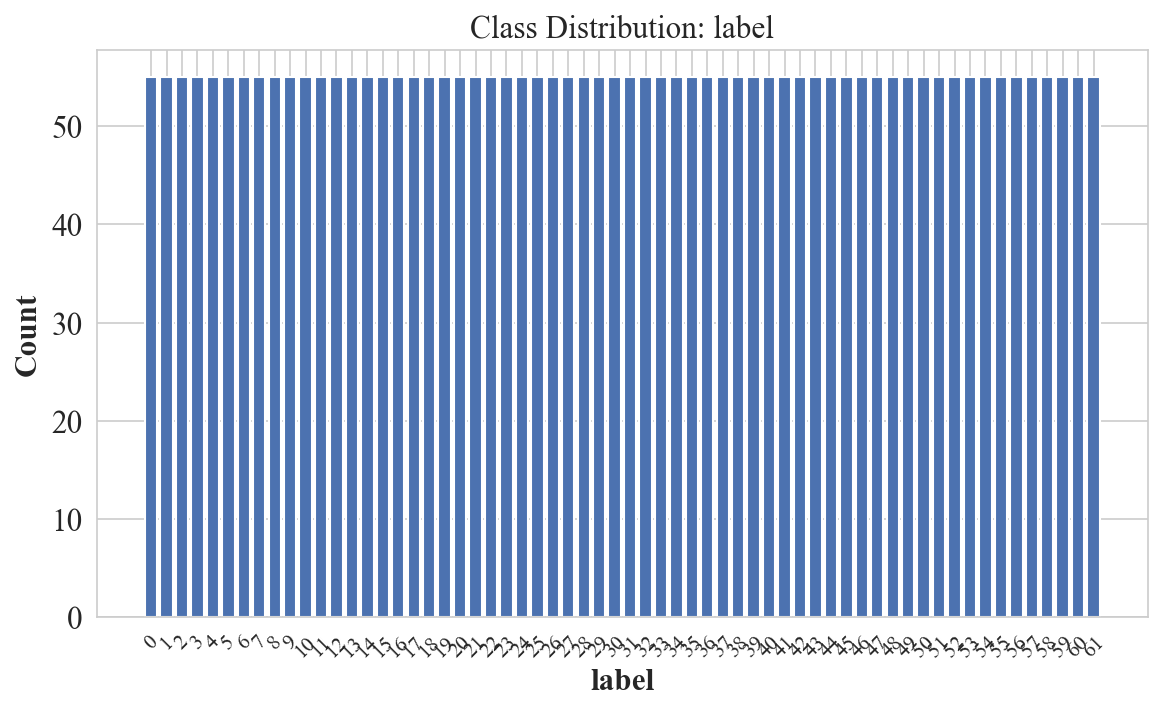

In [5]:
plotTargetOverview(df,target,maxcats=70)

In [6]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=[target]).values
y=df[target].values
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [7]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score,ConfusionMatrixDisplay,roc_curve,precision_recall_curve,auc
from sklearn.preprocessing import label_binarize

fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

singlesize=(8,5)

def setGraphStyle():
    sns.set_style('whitegrid')
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150

def evaluateModel(model,X_train,X_test,y_train,y_test,name="Model"):
    start=time.perf_counter()
    model.fit(X_train,y_train)
    train_time=time.perf_counter()-start
    start=time.perf_counter()
    y_pred=model.predict(X_test)
    pred_time=time.perf_counter()-start
    metrics={"Model":name,"Accuracy":accuracy_score(y_test,y_pred),"Precision":precision_score(y_test,y_pred,average='weighted',zero_division=0),"Recall":recall_score(y_test,y_pred,average='weighted',zero_division=0),"F1 Score":f1_score(y_test,y_pred,average='weighted',zero_division=0),"Training Time":train_time,"Prediction Time":pred_time}
    y_prob=None
    if hasattr(model,"predict_proba"):
        y_prob=model.predict_proba(X_test)
        try:
            if pd.Series(y_test).nunique()==2:
                metrics["ROC-AUC"]=roc_auc_score(y_test,y_prob[:,1])
            else:
                metrics["ROC-AUC"]=roc_auc_score(y_test,y_prob,multi_class="ovr",average="weighted")
        except Exception:
            metrics["ROC-AUC"]=None
    metrics["Confusion Matrix"]=confusion_matrix(y_test,y_pred)
    return metrics,y_pred,y_prob

def runModels(models,X_train,X_test,y_train,y_test):
    results={}
    trained_models={}
    for name,model in models.items():
        metrics,y_pred,y_prob=evaluateModel(model,X_train,X_test,y_train,y_test,name)
        results[name]=metrics
        trained_models[name]=model
    return pd.DataFrame(results).T,trained_models

def printMetrics(metrics):
    print("Accuracy :",metrics["Accuracy"])
    print("Precision :",metrics["Precision"])
    print("Recall :",metrics["Recall"])
    print("F1 Score :",metrics["F1 Score"])
    print("Training Time :",metrics["Training Time"])
    print("Prediction Time :",metrics["Prediction Time"])

def plotConfusionMatrices(trained_models,X_test,y_test):
    setGraphStyle()
    for name,model in trained_models.items():
        y_pred=model.predict(X_test)
        cm=confusion_matrix(y_test,y_pred)
        fig,ax=plt.subplots(figsize=singlesize)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues",ax=ax)
        ax.set_title(f"Confusion Matrix - {name}")
        plt.show()
        plt.close(fig)

def plotROCCurves(trained_models,X_test,y_test):
    setGraphStyle()
    classes=sorted(pd.Series(y_test).unique())
    fig,ax=plt.subplots(figsize=singlesize)
    if len(classes)==2:
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)[:,1]
            fpr,tpr,_=roc_curve(y_test,y_prob)
            ax.plot(fpr,tpr,label=f"{name} (AUC={auc(fpr,tpr):.3f})")
    else:
        y_bin=label_binarize(y_test,classes=classes)
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)
            fpr,tpr,_=roc_curve(y_bin.ravel(),y_prob.ravel())
            ax.plot(fpr,tpr,label=f"{name} (micro-avg AUC={auc(fpr,tpr):.3f})")
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()
    plt.show()
    plt.close(fig)

def plotPRCurves(trained_models,X_test,y_test):
    setGraphStyle()
    classes=sorted(pd.Series(y_test).unique())
    fig,ax=plt.subplots(figsize=singlesize)
    if len(classes)==2:
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)[:,1]
            precision,recall,_=precision_recall_curve(y_test,y_prob)
            ax.plot(recall,precision,label=name)
    else:
        y_bin=label_binarize(y_test,classes=classes)
        for name,model in trained_models.items():
            if not hasattr(model,"predict_proba"):
                continue
            y_prob=model.predict_proba(X_test)
            precision,recall,_=precision_recall_curve(y_bin.ravel(),y_prob.ravel())
            ax.plot(recall,precision,label=f"{name} (micro-avg)")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision Recall Curve")
    ax.legend()
    plt.show()
    plt.close(fig)

def plotAccuracyVsK(results_KNN,title="Accuracy vs k"):
    setGraphStyle()
    k=list(results_KNN.keys())
    accuracy=[results_KNN[i]["Accuracy"] for i in k]
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(k,accuracy,marker='o')
    ax.set_xlabel("k")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True)
    plt.show()
    plt.close(fig)

def plotCVFolds(cv_df,title="Cross-Validation Accuracy"):
    setGraphStyle()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(cv_df['Fold'],cv_df['Train Accuracy'],marker='o',label='Train Accuracy')
    ax.plot(cv_df['Fold'],cv_df['Validation Accuracy'],marker='o',label='Validation Accuracy')
    ax.set_xlabel("Fold")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.show()
    plt.close(fig)

def plotBarComparison(results_df,column,ylabel,title):
    setGraphStyle()
    names=list(results_df.index)
    values=results_df[column].tolist()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(names,values)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x',rotation=15,labelsize=10)
    plt.show()
    plt.close(fig)

def plotGridSearchHeatmap(grid,param_x,param_y,title="GridSearchCV Heatmap"):
    setGraphStyle()
    res=pd.DataFrame(grid.cv_results_)
    pivot=res.pivot_table(values='mean_test_score',index=f'param_{param_y}',columns=f'param_{param_x}',aggfunc='mean')
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(pivot,annot=True,fmt='.3f',cmap='viridis',ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.set_title(title)
    ax.set_xlabel(param_x)
    ax.set_ylabel(param_y)
    plt.show()
    plt.close(fig)

def plotRandomSearchDistribution(search,title="RandomizedSearchCV Score Distribution"):
    setGraphStyle()
    scores=search.cv_results_['mean_test_score']
    fig,ax=plt.subplots(figsize=singlesize)
    ax.hist(scores,bins=10,color='#4C72B0',edgecolor='white')
    ax.axvline(search.best_score_,color='red',linestyle='--',label=f'Best Score={search.best_score_:.3f}')
    ax.set_xlabel("Mean CV Accuracy")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend()
    plt.show()
    plt.close(fig)

def plotLargeConfusionMatrix(model,X_test,y_test,labels,title="Confusion Matrix"):
    setGraphStyle()
    pred=model.predict(X_test)
    cm=confusion_matrix(y_test,pred,normalize='true')
    fig,ax=plt.subplots(figsize=(16,16))
    disp=ConfusionMatrixDisplay(cm,display_labels=labels)
    disp.plot(ax=ax,include_values=False,cmap='Blues',colorbar=True)
    ax.set_title(title)
    plt.xticks(rotation=90,fontsize=6)
    plt.yticks(fontsize=6)
    plt.show()
    plt.close(fig)

In [8]:
import numpy as np

class PLA:
    def __init__(self,lr=0.01,epochs=5):
        self.lr=lr
        self.epochs=epochs
    def fit(self,X,y):
        self.classes_=np.unique(y)
        n,d=X.shape
        self.W=np.zeros((len(self.classes_),d))
        self.b=np.zeros(len(self.classes_))
        for i,c in enumerate(self.classes_):
            yc=np.where(y==c,1,-1)
            w=np.zeros(d)
            bias=0.0
            for epoch in range(self.epochs):
                for j in range(n):
                    score=np.dot(w,X[j])+bias
                    pred=1 if score>=0 else -1
                    update=self.lr*(yc[j]-pred)
                    w=w+update*X[j]
                    bias=bias+update
            self.W[i]=w
            self.b[i]=bias
        return self
    def predict(self,X):
        scores=X@self.W.T+self.b
        idx=np.argmax(scores,axis=1)
        return self.classes_[idx]

In [9]:
pla=PLA(lr=0.01,epochs=5)
metricsPLA,predPLA,probPLA=evaluateModel(pla,Xtrain,Xtest,ytrain,ytest,"PLA")
printMetrics(metricsPLA)

Accuracy : 0.08944281524926687
Precision : 0.0987997359860134
Recall : 0.08944281524926687
F1 Score : 0.08734101905654199
Training Time : 12.630370300030336
Prediction Time : 0.015680499956943095


In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

paramGrid={'hidden_layer_sizes':[(64,),(128,)],'activation':['relu','tanh'],'solver':['adam'],'learning_rate_init':[0.001,0.01]}
mlpSearch=GridSearchCV(MLPClassifier(max_iter=200,random_state=42),paramGrid,cv=3,scoring='accuracy',n_jobs=-1)
mlpSearch.fit(Xtrain,ytrain)
print(mlpSearch.best_params_,mlpSearch.best_score_)

{'activation': 'relu', 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01, 'solver': 'adam'} 0.3431142381637431


In [11]:
bestMLP=MLPClassifier(**mlpSearch.best_params_,max_iter=400,random_state=42)
metricsMLP,predMLP,probMLP=evaluateModel(bestMLP,Xtrain,Xtest,ytrain,ytest,"MLP Tuned")
printMetrics(metricsMLP)

Accuracy : 0.3621700879765396
Precision : 0.38735278822290703
Recall : 0.3621700879765396
F1 Score : 0.36409722999447214
Training Time : 5.323265500017442
Prediction Time : 0.0049706000136211514


               Model  Accuracy Precision    Recall  F1 Score Training Time  \
PLA              PLA  0.089443    0.0988  0.089443  0.087341     10.770972   
MLP Tuned  MLP Tuned   0.36217  0.387353   0.36217  0.364097       6.43924   

          Prediction Time                                   Confusion Matrix  \
PLA              0.001777  [[0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 1, 2,...   
MLP Tuned        0.007045  [[2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,...   

            ROC-AUC  
PLA             NaN  
MLP Tuned  0.896616  


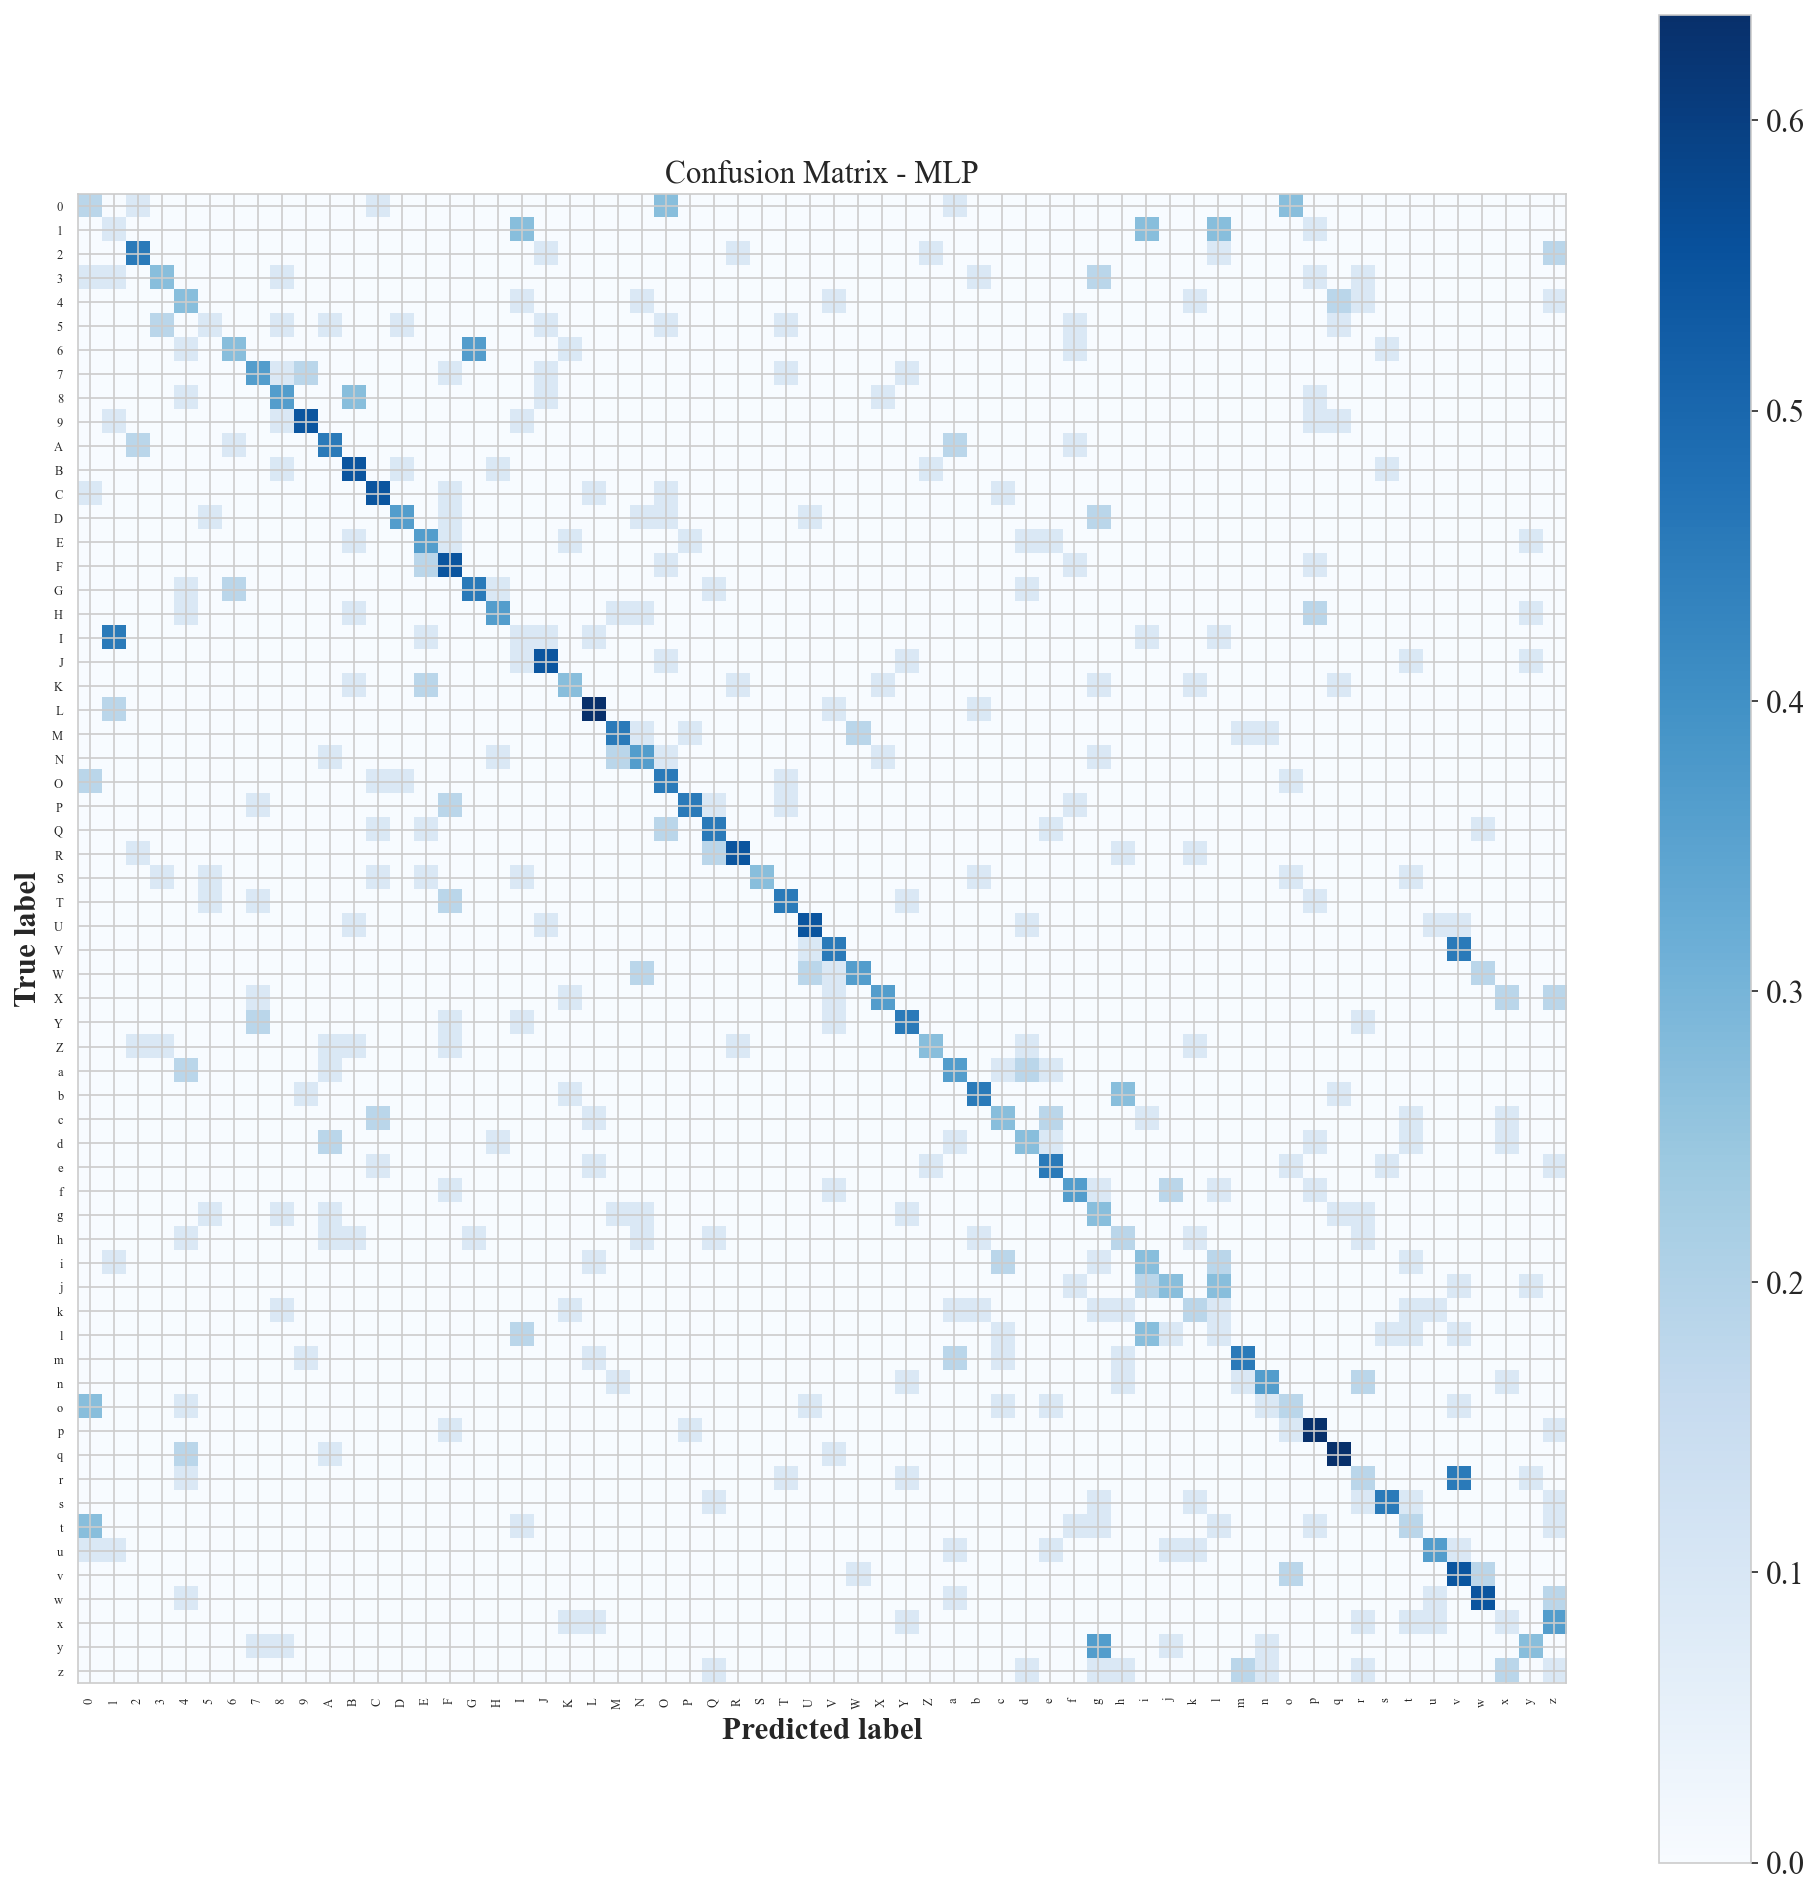

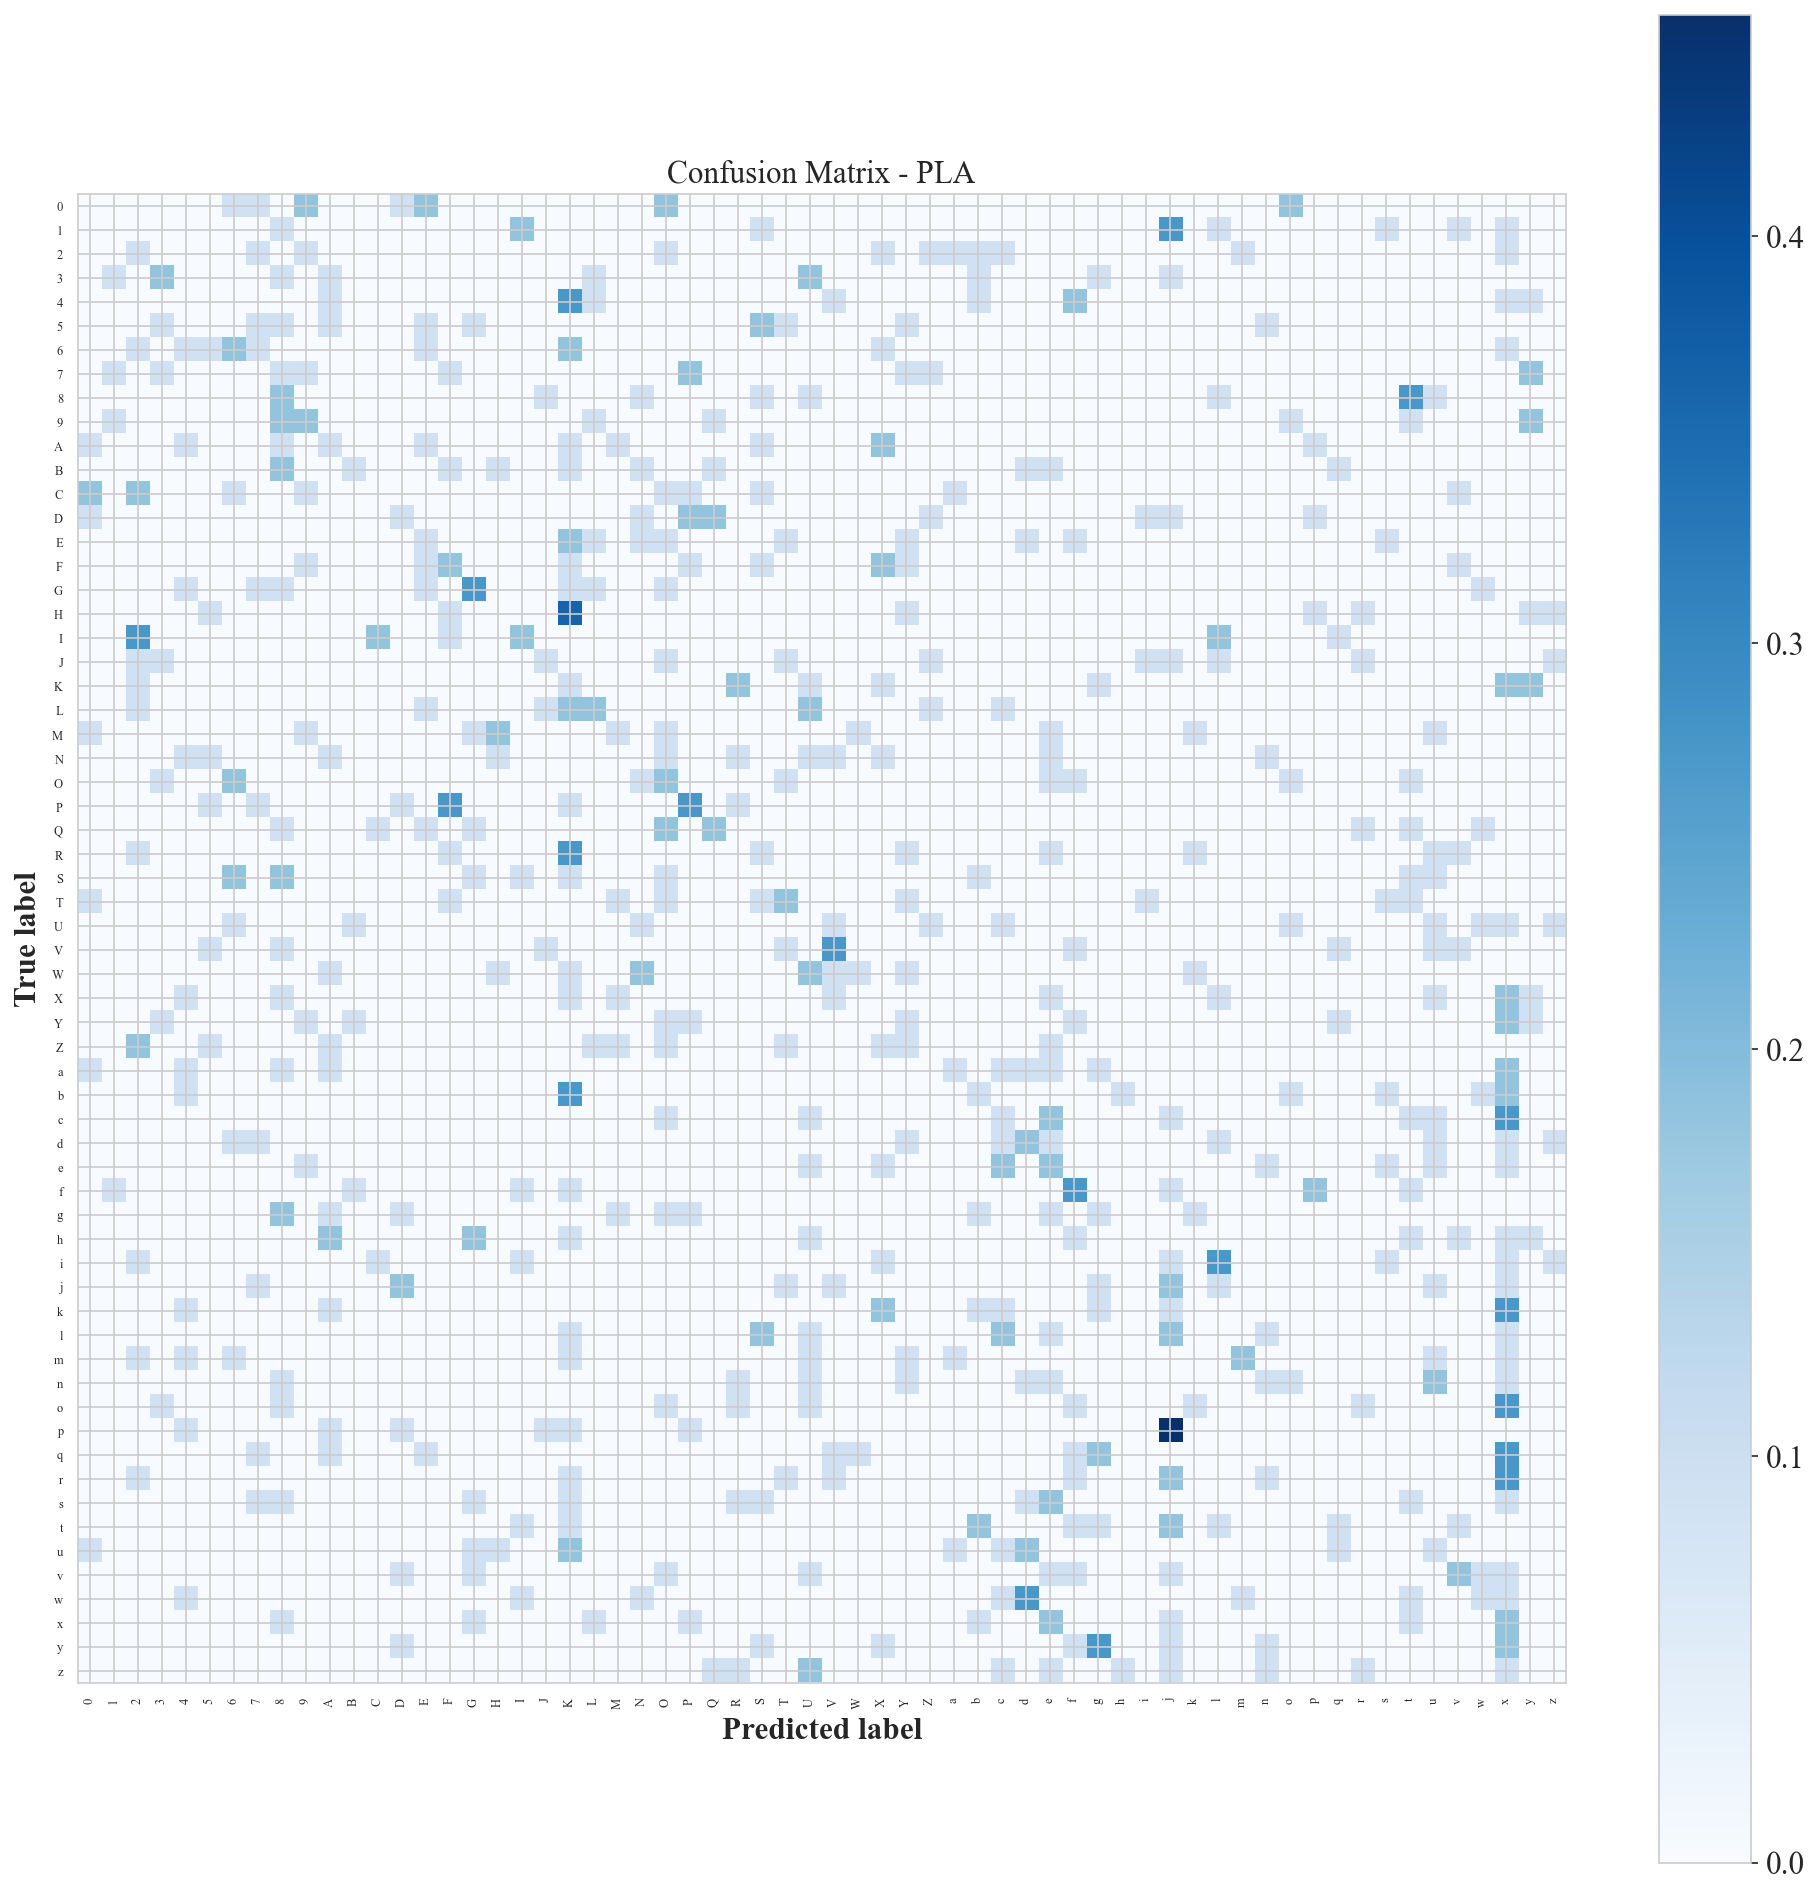

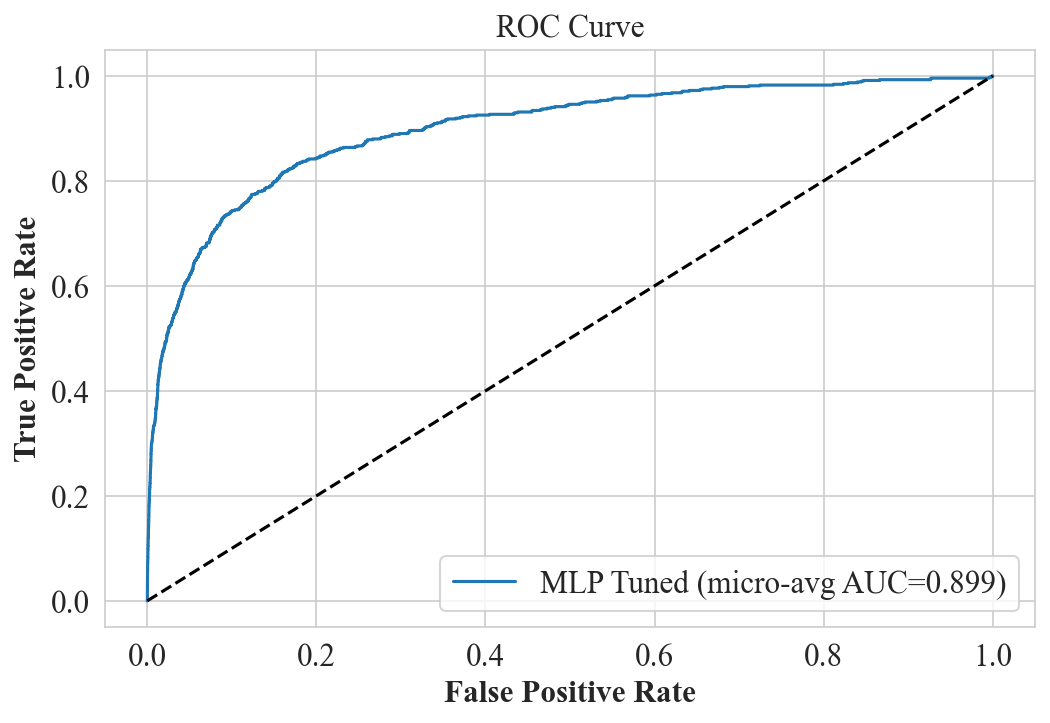

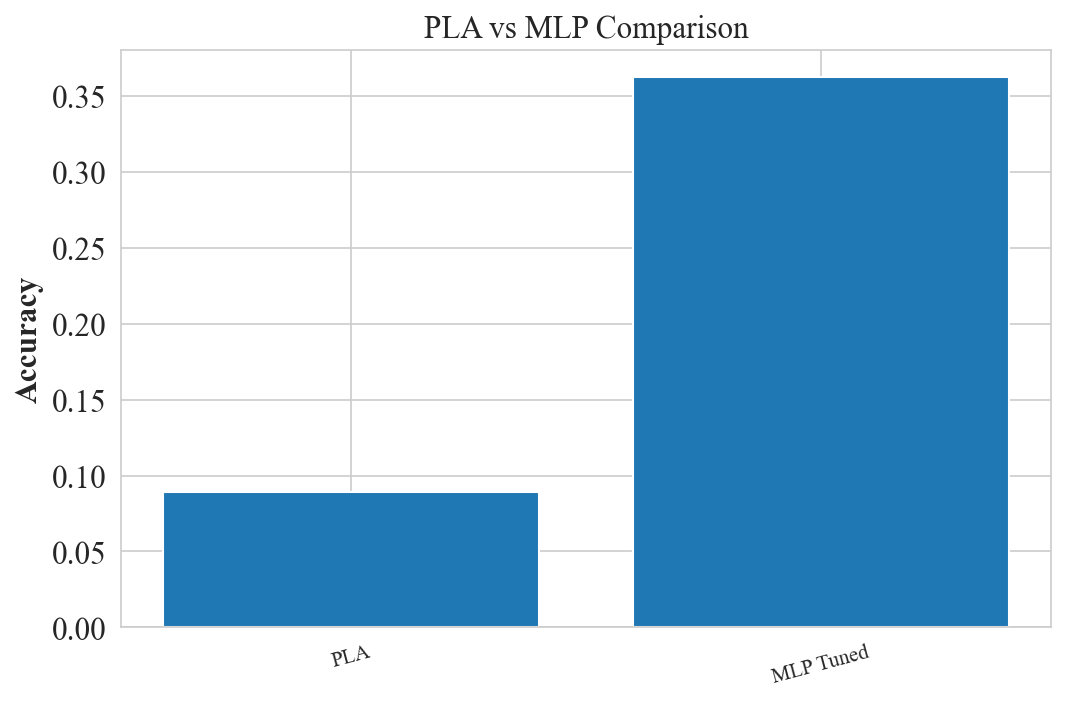

In [12]:
finalModels={"PLA":pla,"MLP Tuned":bestMLP}
finalResults,finalTrained=runModels(finalModels,Xtrain,Xtest,ytrain,ytest)
print(finalResults)
plotLargeConfusionMatrix(bestMLP,Xtest,ytest,enc.classes_,title="Confusion Matrix - MLP")
plotLargeConfusionMatrix(pla,Xtest,ytest,enc.classes_,title="Confusion Matrix - PLA")
plotROCCurves(finalTrained,Xtest,ytest)
plotBarComparison(finalResults,'Accuracy','Accuracy','PLA vs MLP Comparison')